# 1. 논리 회귀
논리 회귀(Logistic Regression)는 주어진 입력 데이터를 기반으로 두 가지 이상의 범주로 분류하는 지도 학습 알고리즘입니다. 주로 이진 분류 문제에 사용되며, 입력 변수의 선형 결합을 통해 특정 사건이 발생할 확률을 예측합니다.

이 알고리즘은 시그모이드(Sigmoid) 함수 또는 로지스틱 함수라는 비선형 함수를 사용하여 예측값을 0과 1 사이의 확률로 변환합니다. 모델의 결과는 일반적으로 특정 임계값(예: 0.5)을 기준으로 두 범주 중 하나로 분류됩니다.

예를 들어, 이메일이 스팸인지 아닌지를 판별하거나 환자의 병 진단 여부를 예측하는 데 사용될 수 있습니다. 논리 회귀는 계산이 비교적 간단하고 해석이 용이하여 머신러닝에서 널리 사용되는 알고리즘입니다.



※ 시그모이드 함수

시그모이드 함수(Sigmoid Function)는 입력 값을 받아서 이를 0과 1 사이의 값으로 변환하는 수학 함수입니다.

주로 확률을 예측해야 하는 문제에서 사용됩니다. 논리 회귀(Logistic Regression)와 인공신경망(Artificial Neural Network)에서 매우 중요한 역할을 합니다. (e: 자연 상수로, 약 2.718입니다.)

# 2. 단항 논리 회귀
단항 논리 회귀 (Univariate Logistic Regression)는 하나의 독립 변수(입력 변수)를 사용하여 이진 분류 문제를 해결하는 논리 회귀(Logistic Regression)의 한 형태입니다.

예를 들어, 학생의 하루 공부 시간(독립 변수)에 따라 시험 합격 여부(종속 변수: 합격/불합격)를 예측하는 경우가 여기에 해당합니다.

단항 논리 회귀는 입력 변수의 값을 시그모이드(Sigmoid) 함수에 전달하여 해당 사건(예: 합격)이 발생할 확률(0과 1 사이의 값)을 계산합니다.

이후 이 확률 값이 특정 임계값(일반적으로 0.5)을 초과하면 한 클래스로, 그렇지 않으면 다른 클래스로 분류합니다.

단항 논리 회귀는 간단하면서도 직관적이어서 이진 분류 문제를 설명하고 해석하는 데 자주 사용됩니다.

In [11]:
import torch
from torch import nn

In [12]:
x = torch.tensor([1.0, 2.0, 3.0])
w = torch.tensor([0.1, 0.2, 0.3])
b = torch.tensor(0.5)

# z = W1*x1 + W2*x2 + W3*x3 + b
# z = 0.1*1.0 + 0.2*2.0 + 0.3*3.0 + 0.5
z = torch.dot(w, x) + b
print(z)

sigmoid = nn.Sigmoid()
output = sigmoid(z)
print(output)

tensor(1.9000)
tensor(0.8699)


torch.Size([8, 1])
torch.Size([8, 1])


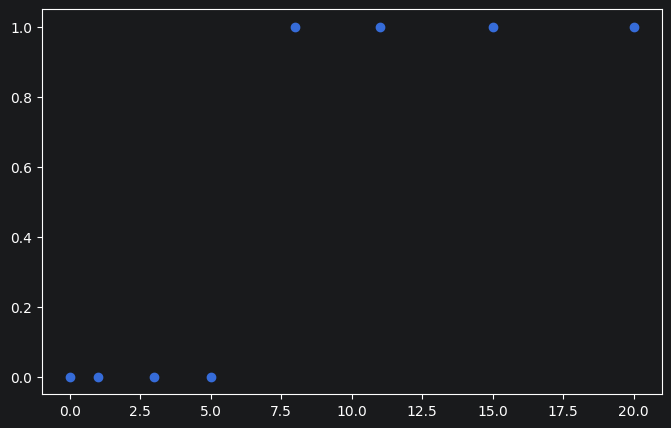

In [13]:
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(2026)

x_train = torch.FloatTensor([[0], [1], [3], [5], [8], [11], [15], [20]])
y_train = torch.FloatTensor([[0], [0], [0], [0], [1], [1], [1], [1]])
print(x_train.shape)
print(y_train.shape)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train)

In [14]:
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

In [15]:
model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): Sigmoid()
)

In [16]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.6950]], requires_grad=True),
 Parameter containing:
 tensor([-0.4962], requires_grad=True)]

In [17]:
y_pred = model(x_train)

In [20]:
print(y_pred)

tensor([[3.7844e-01],
        [2.3304e-01],
        [7.0353e-02],
        [1.8499e-02],
        [2.3372e-03],
        [2.9109e-04],
        [1.8061e-05],
        [5.5911e-07]], grad_fn=<SigmoidBackward0>)


In [21]:
loss = nn.BCELoss()(y_pred, y_train)

loss

tensor(5.0440, grad_fn=<BinaryCrossEntropyBackward0>)

In [22]:
optimizer = optim.SGD(model.parameters(), lr=0.01)


epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(x_train)
    loss = nn.BCELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

Epoch: 0/1000 Loss: 5.043980
Epoch: 100/1000 Loss: 0.395748
Epoch: 200/1000 Loss: 0.367399
Epoch: 300/1000 Loss: 0.343097
Epoch: 400/1000 Loss: 0.322116
Epoch: 500/1000 Loss: 0.303868
Epoch: 600/1000 Loss: 0.287886
Epoch: 700/1000 Loss: 0.273790
Epoch: 800/1000 Loss: 0.261278
Epoch: 900/1000 Loss: 0.250103
Epoch: 1000/1000 Loss: 0.240065


In [23]:
x_test = torch.FloatTensor([[10]])
y_pred = model(x_test)
y_pred

tensor([[0.8531]], grad_fn=<SigmoidBackward0>)

In [24]:
# 임계치 설정하기
# 0.5보다 크거나 같으면 1
# 0.5보다 작으면 0
y_bool = (y_pred >= 0.5).float()
y_bool

tensor([[1.]])